# Lab exam part 2

## Task A: Data Audit & Quality

### Load the dataset and perform an initial audit: identify missing values and handle them appropriately (e.g., imputation or removal).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_excel('data.xlsx', engine='openpyxl')


print("=== Shape ===")
print(df.shape)

print("\n=== First 5 rows ===")
display(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

=== Shape ===
(5630, 20)

=== First 5 rows ===


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.00,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002.00,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003.00,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004.00,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005.00,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60



=== Data Types ===
CustomerID                     float64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


## Dimensionality & Column Selection

Reducing unnecessary complexity is good practice before any analysis begins. 
Columns that carry no predictive signal should be removed immediately, so they 
do not pollute downstream steps such as correlation matrices, missingness analysis, 
and model training.

In this dataset, `CustomerID` is a unique row identifier — it encodes no 
information about customer behaviour and is therefore dropped at the outset.

In [3]:
df = df.drop(columns=['CustomerID'])

In [4]:

print("\n=== Descriptive Statistics ===")
display(df.describe(include='all'))

# --- Missing values audit ---
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_report = missing_report[missing_report['Missing Count'] > 0]\
                               .sort_values('Missing %', ascending=False)

print(missing_report if not missing_report.empty else "No missing values found!")


=== Descriptive Statistics ===


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5366.00,5630,5630.00,5379.00,5630,5628,5375.00,5630.00,5630,5630.00,5630,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
unique,NaN,NaN,4,NaN,NaN,7,2,NaN,NaN,6,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2763,NaN,NaN,2314,3383,NaN,NaN,2050,NaN,2984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.17,10.19,NaN,1.65,15.64,NaN,NaN,2.93,3.69,NaN,3.07,NaN,4.21,0.28,15.71,1.75,3.01,4.54,532.40
std,0.37,8.56,NaN,0.92,8.53,NaN,NaN,0.72,1.02,NaN,1.38,NaN,2.58,0.45,3.68,1.89,2.94,3.65,18842.84
min,0.00,0.00,NaN,1.00,5.00,NaN,NaN,0.00,1.00,NaN,1.00,NaN,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,0.00,2.00,NaN,1.00,9.00,NaN,NaN,2.00,3.00,NaN,2.00,NaN,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,0.00,9.00,NaN,1.00,14.00,NaN,NaN,3.00,4.00,NaN,3.00,NaN,3.00,0.00,15.00,1.00,2.00,3.00,163.33
75%,0.00,16.00,NaN,3.00,20.00,NaN,NaN,3.00,4.00,NaN,4.00,NaN,6.00,1.00,18.00,2.00,3.00,7.00,196.42



=== Missing Values ===
                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46
Gender                                   2       0.04


##  handle missing values
appropriately (e.g., imputation or removal).

In order to handle correctly missing values, we need to first of all understand what these missing vlaues are referrring to - and why they are missing- therefore following the classic scenario we saw in class about potential missing values (missing at random- missing not at random) etc. 

the first thing in my opinion is fully understanding what these indicate. 

Also, to understand if they are missing at random or not, it makes sense to consider whether these missing value are correlated in their missingngess. in fact, imputing them depends on the reason of imputation. 

## Missing Value Analysis

Before imputing missing values, it is important to understand **why** they are missing. 
Following the taxonomy introduced in class, missing data can fall into three categories:

- **MCAR** (Missing Completely At Random): the probability of missingness is unrelated to 
  any observed or unobserved data. Safe to impute or drop.
- **MAR** (Missing At Random): missingness depends on other *observed* variables, 
  but not on the missing value itself. Imputation conditioned on those variables is valid.
- **MNAR** (Missing Not At Random): missingness depends on the unobserved value itself 
  (e.g. customers with very low order counts may not have an `OrderCount` recorded). 
  This is the most problematic case and requires careful handling.

A key diagnostic step is to examine whether missingness is **correlated across columns**: 
if the same rows tend to be missing across multiple features, this suggests a systematic 
pattern (pointing toward MAR or MNAR) rather than random dropout.

=== Columns with missing values ===


,Missing Count,Missing %
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46
Gender,2,0.04


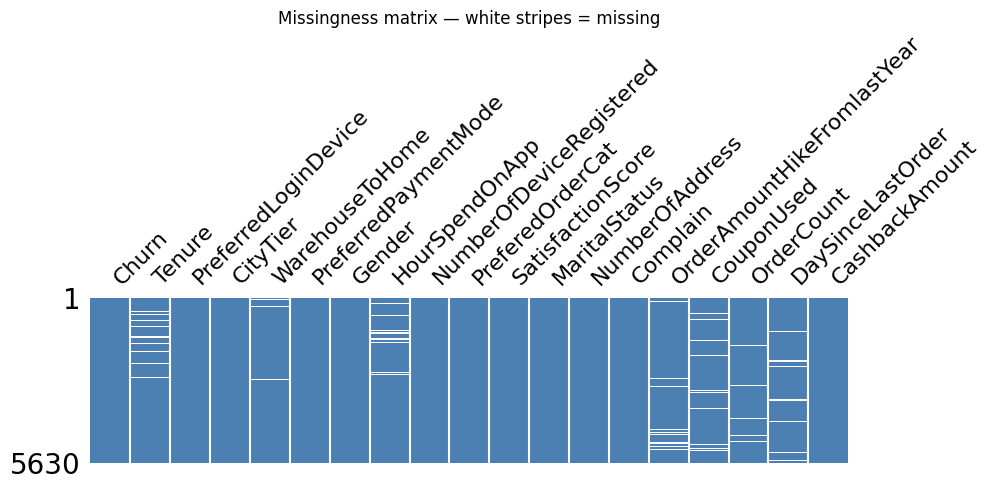

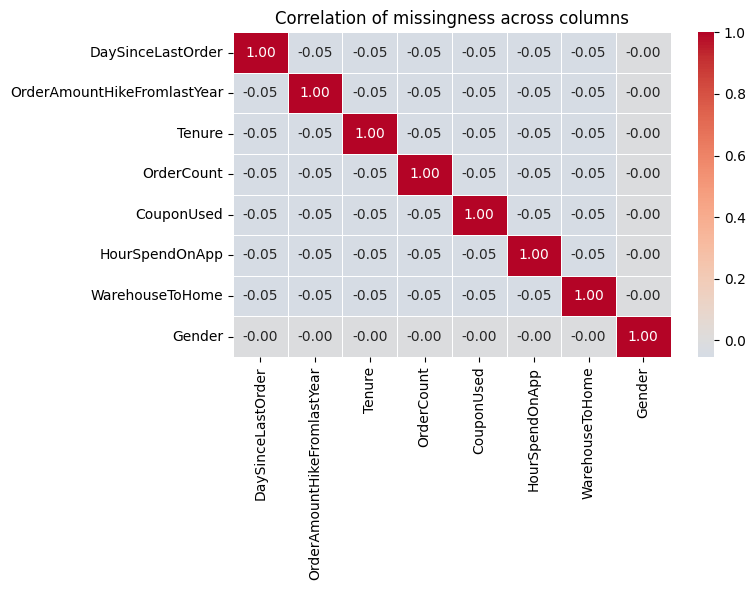

DaySinceLastOrder                   missing churn rate: 17.59%  |  not missing: 16.80%
OrderAmountHikeFromlastYear         missing churn rate: 5.28%  |  not missing: 17.41%
Tenure                              missing churn rate: 30.68%  |  not missing: 16.16%
OrderCount                          missing churn rate: 6.98%  |  not missing: 17.31%
CouponUsed                          missing churn rate: 3.12%  |  not missing: 17.49%
HourSpendOnApp                      missing churn rate: 22.75%  |  not missing: 16.56%
WarehouseToHome                     missing churn rate: 33.47%  |  not missing: 16.06%
Gender                              missing churn rate: 0.00%  |  not missing: 16.84%


In [5]:


import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Summary table ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("=== Columns with missing values ===")
display(missing_report)

# --- 2. Missingness matrix (which rows are missing what) ---
# Rows are sorted by missing pattern — easy to spot clusters
fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(df, ax=ax, sparkline=False, color=(0.3, 0.5, 0.7))
ax.set_title("Missingness matrix — white stripes = missing", fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. Missingness correlation heatmap ---
# Are the same rows missing across multiple columns?
# We build a boolean indicator matrix and compute correlations between columns.
missing_indicators = df[missing_report.index].isnull().astype(int)
corr = missing_indicators.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation of missingness across columns", fontsize=12)
plt.tight_layout()
plt.show()

# --- 4. Are churners more likely to have missing data? (MNAR check) ---
# If yes → missingness is informative and we should consider an indicator variable
for col in missing_report.index:
    missing_flag = df[col].isnull()
    churn_rate_missing    = df.loc[missing_flag,  'Churn'].mean()
    churn_rate_not_missing = df.loc[~missing_flag, 'Churn'].mean()
    print(f"{col:<35} missing churn rate: {churn_rate_missing:.2%}  |  "
          f"not missing: {churn_rate_not_missing:.2%}")

The correlation heatmap shows near-zero pairwise correlations (≈ −0.05) between 
missingness indicators across all affected columns. This small negative value is a 
mathematical artifact of low missingness rates (~3–5% per column) rather than a 
meaningful signal: it simply reflects the fact that missing rows are largely 
non-overlapping across features.

This allows us to **rule out a systematic block-missing pattern** — for instance, 
a customer skipping an entire section of a form, which would have produced strong 
positive correlations. Each column appears to be missing independently of the others.

However, this result only addresses the **MAR** dimension between columns. It does 
not rule out **MNAR**: a column's values could still be missing *because of* the 
value itself (e.g. customers with very low tenure may simply not have a tenure 
recorded). This will be investigated in the next step.

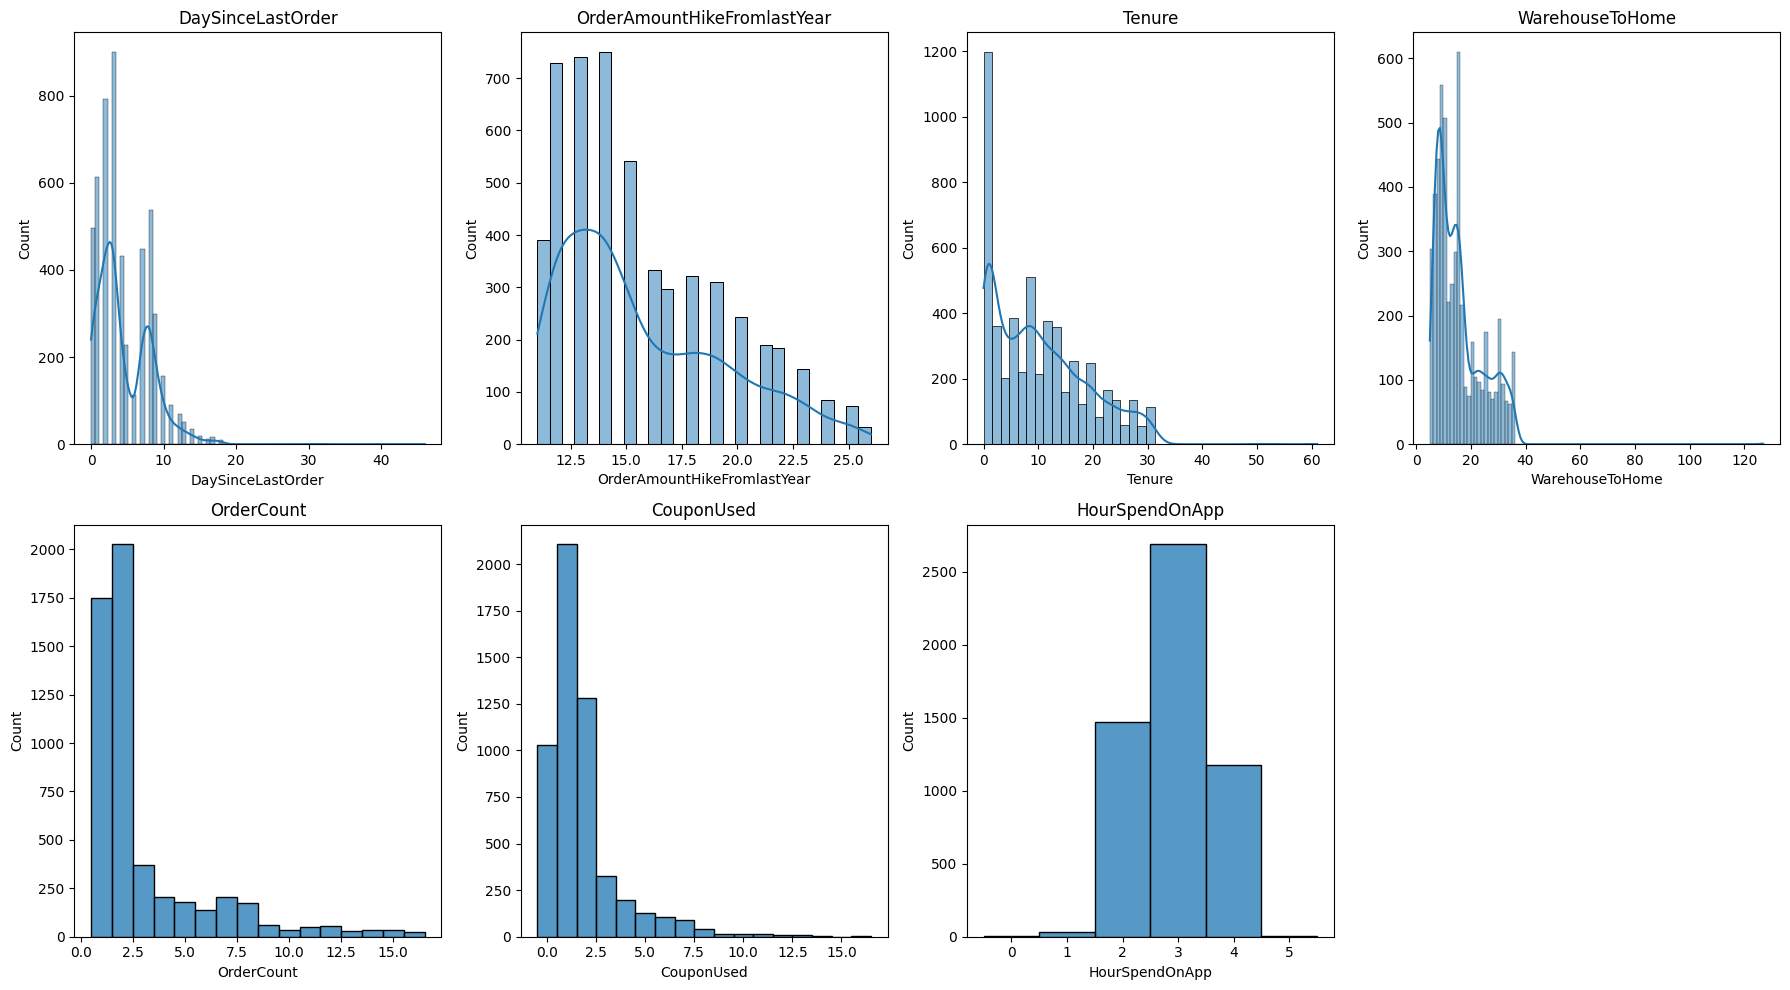

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# 1. Plot Continuous variables with a KDE (Kernel Density Estimate) smooth curve
continuous_cols = ['DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 'WarehouseToHome']
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# 2. Plot Discrete/Integer variables cleanly
discrete_cols = ['OrderCount', 'CouponUsed', 'HourSpendOnApp']
for i, col in enumerate(discrete_cols):
    # Setting discrete=True forces the bins to align perfectly with integers
    sns.histplot(df[col], discrete=True, ax=axes[i+len(continuous_cols)])
    axes[i+len(continuous_cols)].set_title(col)

# Hide the last empty subplot (since we have 7 columns and an 8-panel grid)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Handling Missing Values

To develop a mathematically sound strategy for handling missing values, it is crucial to first understand what the variables represent, whether the data is continuous or discrete, and how the underlying distributions are shaped (e.g., Gaussian vs. skewed). Simply applying a blind, one-size-fits-all formula risks distorting the business logic of the dataset.

Therefore, the preprocessing strategy is broken down as follows:

#### 1. Deletion

* **`Gender`:** Only 2 rows out of 5,630 are missing (0.04%). Any imputation strategy here would be statistically negligible and risks introducing artificial demographic bias. Therefore, these specific rows are simply dropped.

#### 2. Imputation Strategy (Median, Mode, and Indicators)

Visualizing the distributions via histograms revealed that none of our numerical variables follow a perfect normal (Gaussian) distribution, ruling out Mean imputation. Instead, a tailored approach using the Median and Mode is applied based on the data type:

**A. Continuous Variables (Imputing the Median)**
For continuous variables, the visual audit showed significant right-skewness. In these cases, the Median is strictly superior to the Mean because it protects the data from being artificially dragged upward by extreme outliers.

* **`WarehouseToHome`:** Distance is strictly positive and heavily right-skewed. While most customers live within a standard delivery radius, a few live anomalous distances away. The median accurately captures the true "typical" customer distance.
* **`OrderAmountHikeFromlastYear`:** Percentage increases are notoriously volatile. If the vast majority of customers increased spending by 5-10%, but one corporate buyer increased spending by 800%, the mean is ruined. The median safely represents standard customer growth.
* **`Tenure`:** Also right-skewed, the median safely estimates the typical account lifespan without being inflated by a few legacy "power users."

**B. Discrete Variables (Imputing the Mode)**
For physical counts of actions or items, the data is discrete. While the median can sometimes result in clean integers, the Mode is mathematically tighter because it assigns missing rows to the most common real-world behavioral cohort.

* **`CouponUsed` & `OrderCount`:** A customer cannot use 1.8 coupons or place 3.4 orders. Imputing with the Mode ensures our synthetic data remains grounded in logical reality.

#### 3.  Conditional Imputation : Behavioral Variables (`DaySinceLastOrder` and `Tenure`)

While global median imputation is safe for standalone metrics, deep behavioral variables are logically intertwined with customer engagement. Applying a global median here risks creating synthetic profiles that contradict business logic. Therefore, these features require a conditional approach:

* **`DaySinceLastOrder` (5.45% Missing):** Deletion was not an option due to the volume of missing rows. To ensure we weren't overwriting a structural business rule, two hypotheses were tested:
1. *Is the missingness systematically related to other columns?* The correlation heatmap showed near-zero pairwise correlations (≈ −0.05) between missingness indicators, meaning this data is not dropping out in tandem with other features.
2. *Could a missing value actually mean the customer has never placed an order?* By applying a boolean mask, it was confirmed that `OrderCount == 0` does not exist anywhere in the dataset (the minimum is 1).


Therefore, a missing `DaySinceLastOrder` reflects a database recording gap rather than a lack of historical activity. Instead of a global median, these missing values are conditionally imputed by grouping customers into cohorts based on their `CityTier` or `PreferredLoginDevice`. This maintains the natural variance in engagement velocity across different demographic segments.
* **`Tenure` (4.68% Missing):** Assigning an average global tenure to a customer with only one lifetime order mathematically misrepresents their loyalty. Instead, missing `Tenure` values are conditionally imputed by grouping customers into cohorts based on their `OrderCount` (e.g., low, medium, and high-frequency buyers). The missing `Tenure` is then filled using the median of their specific cohort, preserving the logical correlation between purchasing frequency and account lifespan.


#### 4. The Safety Net: Missingness Indicators

Finally, replacing a missing value (even with a statistically sound Median or Mode) technically hides information from the machine learning algorithm. To prevent any loss of predictive signal, a **Missingness Indicator** (`add_indicator=True`) is added for every imputed column.

This creates a new binary column that flags exactly where data was missing. If the *absence* of data is actually a behavioral signal for churning (MNAR - Missing Not At Random), the model can now natively capture that relationship without us having to mathematically prove it beforehand.





In [7]:
import pandas as pd
import numpy as np

# Create a clean copy of the data to avoid Jupyter state errors
df_imputed = df.copy()

# ==========================================
# STEP 4: ADD INDICATORS FIRST
# We must do this before any imputation, otherwise the 'NaN's disappear!
# ==========================================
cols_to_impute = [
    'WarehouseToHome', 'OrderAmountHikeFromlastYear', 'Tenure', 
    'CouponUsed', 'OrderCount', 'HourSpendOnApp', 'DaySinceLastOrder'
]

for col in cols_to_impute:
    # Creates a new column (e.g., 'Tenure_is_missing') with 1 if missing, 0 if not
    df_imputed[f'{col}_is_missing'] = df_imputed[col].isnull().astype(int)

# ==========================================
# STEP 1: DELETION
# ==========================================
# Drop the 2 rows where Gender is missing
df_imputed = df_imputed.dropna(subset=['Gender'])

# ==========================================
# STEP 2B: DISCRETE VARIABLES (MODE)
# Note: We must impute OrderCount BEFORE Tenure, because Tenure relies on it!
# ==========================================
mode_cols = ['CouponUsed', 'OrderCount']

for col in mode_cols:
    # .mode()[0] extracts the most frequent value
    mode_value = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_value)

# ==========================================
# STEP 3: CONDITIONAL IMPUTATION (BEHAVIORAL)
# ==========================================
# 3A. Tenure (Grouped by OrderCount Cohorts)
# First, create the low/medium/high cohorts
df_imputed['OrderCount_Cohort'] = pd.cut(
    df_imputed['OrderCount'], 
    bins=[0, 2, 5, np.inf], # 1-2: Low, 3-5: Med, 6+: High
    labels=['Low', 'Medium', 'High']
)

# Impute missing Tenure with the median of their specific cohort
df_imputed['Tenure'] = df_imputed.groupby('OrderCount_Cohort')['Tenure'].transform(
    lambda x: x.fillna(x.median())
)

# 3B. DaySinceLastOrder (Grouped by CityTier)
df_imputed['DaySinceLastOrder'] = df_imputed.groupby('CityTier')['DaySinceLastOrder'].transform(
    lambda x: x.fillna(x.median())
)

# Fallback safety: If any cohort was completely empty (very rare), fill remaining with global median
df_imputed['Tenure'] = df_imputed['Tenure'].fillna(df_imputed['Tenure'].median())
df_imputed['DaySinceLastOrder'] = df_imputed['DaySinceLastOrder'].fillna(df_imputed['DaySinceLastOrder'].median())

# Clean up: remove the temporary cohort column
df_imputed = df_imputed.drop(columns=['OrderCount_Cohort'])

# ==========================================
# STEP 2A: CONTINUOUS VARIABLES (GLOBAL MEDIAN)
# ==========================================
median_cols = ['WarehouseToHome', 'OrderAmountHikeFromlastYear', 'HourSpendOnApp']

for col in median_cols:
    median_value = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_value)

# ==========================================
# FINAL SANITY CHECK
# ==========================================
print("Remaining missing values:")
print(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_86400/469688930.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_imputed['Tenure'] = df_imputed.groupby('OrderCount_Cohort')['Tenure'].transform(



### Task A, Part B: Data Consistency and Outliers

**1. Data Consistency Check**
To understand whether there is data consistency, as usual, the first step is to look at what the data actually represents. This is the only way to know if the numbers make physical sense in the real world.

For example, `Tenure` represents the number of months a customer has been with the company, so it obviously cannot be a negative number. The same logic applies to `WarehouseToHome`, which represents a physical distance and therefore must be positive. Similarly, engagement metrics like `OrderCount` cannot be anything other than a positive integer count.

To check these variables, running `df_imputed.describe()` and looking purely at the `min` row instantly tells us if there are any "impossible" negative values sitting in the dataset. If the minimums are all 0 or positive, the data is logically consistent. To be absolutely certain, I ran an automated validation check across all physical metrics, which confirmed that no minimum values dropped below zero. The data is logically sound.




In [8]:
df_imputed.describe()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,OrderCount,DaySinceLastOrder,CashbackAmount,WarehouseToHome_is_missing,OrderAmountHikeFromlastYear_is_missing,Tenure_is_missing,CouponUsed_is_missing,OrderCount_is_missing,HourSpendOnApp_is_missing,DaySinceLastOrder_is_missing
count,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,...,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00,5628.00
mean,0.17,10.10,1.65,15.56,2.93,3.69,3.07,4.21,0.28,15.67,...,2.96,4.46,532.54,0.04,0.05,0.05,0.05,0.05,0.05,0.05
std,0.37,8.37,0.92,8.34,0.71,1.02,1.38,2.58,0.45,3.59,...,2.88,3.57,18846.18,0.21,0.21,0.21,0.21,0.21,0.21,0.23
min,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,3.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,...,1.00,2.00,145.77,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,8.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,...,2.00,3.00,163.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,15.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,...,3.00,7.00,196.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,...,16.00,46.00,999999.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [9]:
physical_metrics = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 
    'OrderCount', 'DaySinceLastOrder'
]

inconsistent_cols = [col for col in physical_metrics if df_imputed[col].min() < 0]

if len(inconsistent_cols) == 0:
    print("Data Consistency Check Passed: No negative values found in physical/time metrics.")
else:
    print(f"WARNING: Inconsistent negative data found in: {inconsistent_cols}")

Data Consistency Check Passed: No negative values found in physical/time metrics.


the second part is about data consistency. is data in the correct format?

In [10]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5628 entries, 0 to 5629
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Churn                                   5628 non-null   int64  
 1   Tenure                                  5628 non-null   float64
 2   PreferredLoginDevice                    5628 non-null   object 
 3   CityTier                                5628 non-null   int64  
 4   WarehouseToHome                         5628 non-null   float64
 5   PreferredPaymentMode                    5628 non-null   object 
 6   Gender                                  5628 non-null   object 
 7   HourSpendOnApp                          5628 non-null   float64
 8   NumberOfDeviceRegistered                5628 non-null   int64  
 9   PreferedOrderCat                        5628 non-null   object 
 10  SatisfactionScore                       5628 non-null   int64  
 

### Structural Consistency: Data Type (Dtype) Audit

Before performing any outlier analysis or engineering features, a thorough structural consistency audit is required.  Now that all missing values have been cleanly imputed, we must correct these data types. Leaving discrete counts as floats can cause downstream machine learning models to interpret them as continuous scales, which misrepresents the underlying business logic.

The table below details the conceptual nature of every variable, its current state in the dataframe, and the required structural adjustments.

| Column Name | Conceptual Definition | Current Dtype | Target Dtype | Justification & Structural Choice |
| --- | --- | --- | --- | --- |
| **Churn** | Target variable. Binary indicator (0 = Stayed, 1 = Churned). | `int64` | `int64` | **Correct.** Structurally sound as a binary integer. |
| **Tenure** | Lifespan of customer account in whole months. | `float64` | `int64` | **Adjustment Needed.** Imputation forced this to float. Account lifespan is tracked in discrete monthly units here; casting to integer preserves this constraint. Tenure Justification: > "Account lifespan is tracked natively by the business in discrete, whole monthly units, as evidenced by the lack of fractional months in the raw data. The column was automatically upcast to float64 by Pandas solely due to the presence of missing values (NaN). Now that imputation is complete, casting it back to int64 restores the true structural constraint of the metric and prevents models from treating it as a continuous decimal scale."|
| **PreferredLoginDevice** | Terminal/device used to log in. Nominal categorical. | `object` | `object` | **Correct.** Text representation of distinct categories. |
| **CityTier** | Classification of customer's city (Tier 1, 2, 3). Nominal categorical. | `int64` | `object` | **Adjustment Needed.** Currently stored as an integer, which would lead a linear model to treat Tier 3 as numerically "greater than" Tier 1 by a fixed, equal margin — an assumption the data does not support. While a natural real-world ordering exists (Tier 1 = major metros, descending urbanisation), the churn rates by tier (Tier 1: 15%, Tier 2: 20%, Tier 3: 21%) reveal that the intervals are highly unequal: Tier 2 and Tier 3 are nearly identical in churn behaviour, while the real gap lies between Tier 1 and everyone else. Preserving a 1→2→3 integer scale would force the model to treat these unequal jumps as equivalent. Converting to unordered nominal categories and applying one-hot encoding allows the model to discover each tier's effect independently, without imposing a false metric distance between them. |
| **WarehouseToHome** | Distance from warehouse to home. Continuous numeric. | `float64` | `float64` | **Correct.** Distance is a true continuous metric that can handle decimal values. |
| **PreferredPaymentMode** | Customer's payment method. Nominal categorical. | `object` | `object` | **Correct.** Text strings representing non-ordered categories. |
| **Gender** | Customer gender. Nominal categorical. | `object` | `object` | **Correct.** Text representation. Missing rows were dropped. |
| **HourSpendOnApp** | Total hours spent on the application. Discrete count. | `float64` | `int64` | **Adjustment Needed.** Sliced as whole integer blocks (0 to 5 hours) in the source data. Must be cast to integer to reflect its discrete nature. |
| **NumberOfDeviceRegistered** | Total devices linked to the account. Discrete count. | `int64` | `int64` | **Correct.** Already recognized as a discrete integer. |
| **PreferedOrderCat** | Most frequent purchase category. Nominal categorical. | `object` | `object` | **Correct.** Text categories. |
| **SatisfactionScore** | Customer feedback rating on a scale from 1 to 5. Ordinal discrete. | `int64` | `int64` | **Correct.** Whole integer scale. |
| **MaritalStatus** | Customer marital status. Nominal categorical. | `object` | `object` | **Correct.** Text categories. |
| **NumberOfAddress** | Number of addresses registered. Discrete count. | `int64` | `int64` | **Correct.** Whole integer count. |
| **Complain** | Flag for complaints filed in the last month (0 = No, 1 = Yes). Binary. | `int64` | `int64` | **Correct.** Binary indicator represented as an integer. |
| **OrderAmountHikeFromlastYear** | Percentage increase in spending. Continuous numeric. | `float64` | `float64` | **Correct.** Percentages are continuous and mathematically valid as floats. |
| **CouponUsed** | Number of coupons redeemed. Discrete count. | `float64` | `int64` | **Adjustment Needed.** Upcast to float due to missing values. A customer cannot redeem 1.5 coupons; must be cast back to a discrete integer. |
| **OrderCount** | Number of orders placed this year. Discrete count. | `float64` | `int64` | **Adjustment Needed.** Upcast to float due to missing values. Orders occur in whole units; must be cast back to an integer. |
| **DaySinceLastOrder** | Recency of last purchase in days. Discrete count. | `float64` | `int64` | **Adjustment Needed.** Upcast to float due to missing values. Days are tracked as whole integers in this context; requires casting to match business reality. |
| **CashbackAmount** | Monetary value rewarded to customer. Continuous financial. | `float64` | `float64` | **Correct.** Currency metrics are inherently continuous. |
| ***_is_missing** | All 7 engineered missingness indicators. Binary. | `int64` | `int64` | **Correct.** Clean flags represented as 0 or 1. |

---


In [11]:
discrete_int_cols = [
    'Tenure',           # whole months
    'HourSpendOnApp',   # whole hours (0–5 in source data)
    'CouponUsed',       # whole coupon count
    'OrderCount',       # whole order count
    'DaySinceLastOrder' # whole day count
]

df_imputed[discrete_int_cols] = df_imputed[discrete_int_cols].astype('int64')


# ── 2. Convert CityTier from numeric integer to nominal string ───────────────
# CityTier holds labels (1, 2, 3) that represent unordered city classifications,
# not a numeric scale. Storing it as int64 would mislead linear models into
# treating Tier 3 as "3× greater than" Tier 1. Converting to string dtype
# prevents false numeric interpretation and prepares it for one-hot encoding.

df_imputed['CityTier'] = df_imputed['CityTier'].astype(str)

**2. Handling Outliers (`WarehouseToHome` and `Tenure` ranges)**
With consistency confirmed, the next step is addressing the extreme ranges. As we saw in the distribution histograms earlier, both `WarehouseToHome` and `Tenure` are heavily right-skewed with extreme high-end outliers (e.g., a maximum distance of 127 miles and a maximum tenure of 61 months).

How to deal with outliers is also highly dependant on what models we are planning to use. When considering models such as ANNs or logistic regression, they might in fact calculate the mathematical distance and desire calculating the distance using it. However, this is different from those cases where, instead, we might wqant to use tree algorithms, as they usually cap at the higher end and use "rules" likely inferior vs superior to. as xgBoost are often less sensible to outliers. A solution could actually be having a pipeline for different models as we want to experiment.

the two possibilities for dealing with outliers could be 3xIQR and capping extreme values.

it is also relevant understanding wether those outliers are actually data entry error, or if they are , in fact, actual values, although more extreme than usual. and in that case, they would be needed to be kept.


to see the actual outliers it would make sense to use boxplot.

While it might be tempting to cap these extreme values (Winsorization), I decided to leave them in their true state. In Task C, we are required to build a propensity model, and I will be using tree-based algorithms (like Random Forest and XGBoost). Because tree-based models make decisions by splitting nodes rather than drawing linear equations, they are naturally robust to extreme outliers. Retaining these exact numbers preserves the genuine, natural variance of our extreme customers without risking a drop in model performance.



**2. Handling Outliers (`WarehouseToHome` and `Tenure` ranges)**

With structural consistency confirmed, we now turn to distributional integrity. The histograms above reveal that both `WarehouseToHome` and `Tenure` are heavily right-skewed, with isolated high-end values — a maximum warehouse distance of 127 km and a maximum customer tenure of 61 months — that warrant closer inspection.

Before deciding how to treat these values, two questions need to be answered in sequence.

The first is whether they are genuine data or entry errors. A distance of 127 km from a warehouse is plausible for a domestic e-commerce platform operating across a large country; a tenure of 61 months is equally realistic for a long-standing customer. Neither value crosses a logical impossibility threshold — unlike, say, a negative tenure or a distance of 5,000 km. These are therefore treated as legitimate extreme values rather than corrupted records.

The second question is how the chosen algorithm responds to extreme magnitudes — and here the answer is model-dependent. Linear models such as Logistic Regression minimise a squared-error loss function, meaning a value 10× above the mean contributes 100× more to the loss. A single extreme point can pull the decision boundary toward itself, distorting predictions for the majority of normal customers. Tree-based models work differently: they make binary splits on thresholds, asking only whether a value is above or below a cut-off. A customer living 80 km from a warehouse and one living 500 km away both end up in the same branch once the split is drawn at, say, 75 km — the magnitude beyond the threshold is irrelevant.

Since Task C requires at least two algorithms, I will implement both a Logistic Regression baseline and an XGBoost challenger, evaluated on the same held-out test set to ensure a fair comparison. This requires two separate preprocessing pipelines. For XGBoost, outliers are left in their true state, preserving the genuine variance in the data. For Logistic Regression, extreme values in continuous features will be capped at the 3×IQR upper fence — a technique known as Winsorization — which neutralises their disproportionate influence on the gradient without discarding the records entirely.

The outliers are visualised below using box plots, which make the position and scale of extreme values immediately readable.



**2. Handling Outliers — distributional analysis**

With structural consistency confirmed, we now examine the distributions of all continuous and discrete-count features. The histograms above reveal a clear split in behaviour across the numeric columns.

`OrderAmountHikeFromlastYear` and `HourSpendOnApp` require no outlier treatment. The former follows an approximately symmetric distribution centred around 15–17%; the latter is a bounded discrete variable ranging from 0 to 5, peaking at 3 hours — by definition it cannot have extreme values.

The remaining numeric features — `Tenure`, `WarehouseToHome`, `DaySinceLastOrder`, `OrderCount`, and `CouponUsed` — are all right-skewed to varying degrees, with long tails tapering gradually toward high-end values. Crucially, these tails are continuous rather than isolated: there is no evidence of a lone point detached from the rest of the distribution, which would suggest a data entry error. A customer with 61 months of tenure or a warehouse distance of 120 km is plausible within a large domestic e-commerce context, and both values sit at the natural extreme of an otherwise coherent distribution.

Before deciding on treatment, the relevant question is whether these extreme magnitudes will distort the models we intend to use. Since Task C requires at least two algorithms, I will implement both a Logistic Regression baseline and an XGBoost challenger. The two families respond to outliers in fundamentally different ways, which requires two separate preprocessing pipelines evaluated on the same held-out test set.

For XGBoost, extreme values are left untouched. Tree-based splits operate on thresholds — a customer 20 km from the warehouse and one 120 km away both fall into the same branch once the cut-off is drawn. The magnitude beyond the split is irrelevant, so capping would only destroy real variance without improving the model.

For Logistic Regression, the same values pose a genuine problem. The algorithm minimises a loss function that squares prediction errors, meaning a value 10× above the mean contributes 100× more to the gradient. A single extreme point can pull the decision boundary toward itself, distorting predictions for the majority of normal customers. Extreme values in the affected columns will therefore be capped at the 3×IQR upper fence — a technique known as Winsorization — which neutralises their disproportionate influence without removing the records from the training set.

The box plots below make the position and relative scale of these extremes directly readable before any treatment is applied.


In [12]:
# Features screened for outliers.
# Excluded: HourSpendOnApp (hard-bounded 0–5), SatisfactionScore (hard-bounded 1–5),
# binary columns, categorical columns, and _is_missing indicators.

outlier_cols = [
    'WarehouseToHome',
    'Tenure',
    'DaySinceLastOrder',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'CashbackAmount',
    'NumberOfAddress',
]

k = 3  # 1.5 = mild outliers (Tukey standard), 3 = extreme outliers only

records = []
for col in outlier_cols:
    Q1  = df_imputed[col].quantile(0.25)
    Q3  = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    n_below = (df_imputed[col] < lower).sum()
    n_above = (df_imputed[col] > upper).sum()
    n_total = n_below + n_above

    records.append({
        'Feature':        col,
        'Q1':             round(Q1, 2),
        'Q3':             round(Q3, 2),
        'IQR':            round(IQR, 2),
        'Lower fence':    round(lower, 2),
        'Upper fence':    round(upper, 2),
        '↓ below fence':  n_below,
        '↑ above fence':  n_above,
        'Total outliers': n_total,
        '% of dataset':   round(100 * n_total / len(df_imputed), 2)
    })

outlier_summary = pd.DataFrame(records).set_index('Feature')
display(outlier_summary)

,Q1,Q3,IQR,Lower fence,Upper fence,↓ below fence,↑ above fence,Total outliers,% of dataset
Feature,,,,,,,,,
WarehouseToHome,9.00,20.00,11.00,-24.00,53.00,0,2,2,0.04
Tenure,3.00,15.00,12.00,-33.00,51.00,0,2,2,0.04
DaySinceLastOrder,2.00,7.00,5.00,-13.00,22.00,0,3,3,0.05
OrderAmountHikeFromlastYear,13.00,18.00,5.00,-2.00,33.00,0,0,0,0.00
CouponUsed,1.00,2.00,1.00,-2.00,5.00,0,303,303,5.38
OrderCount,1.00,3.00,2.00,-5.00,9.00,0,263,263,4.67
CashbackAmount,145.77,196.43,50.66,-6.21,348.41,0,2,2,0.04
NumberOfAddress,2.00,6.00,4.00,-10.00,18.00,0,4,4,0.07


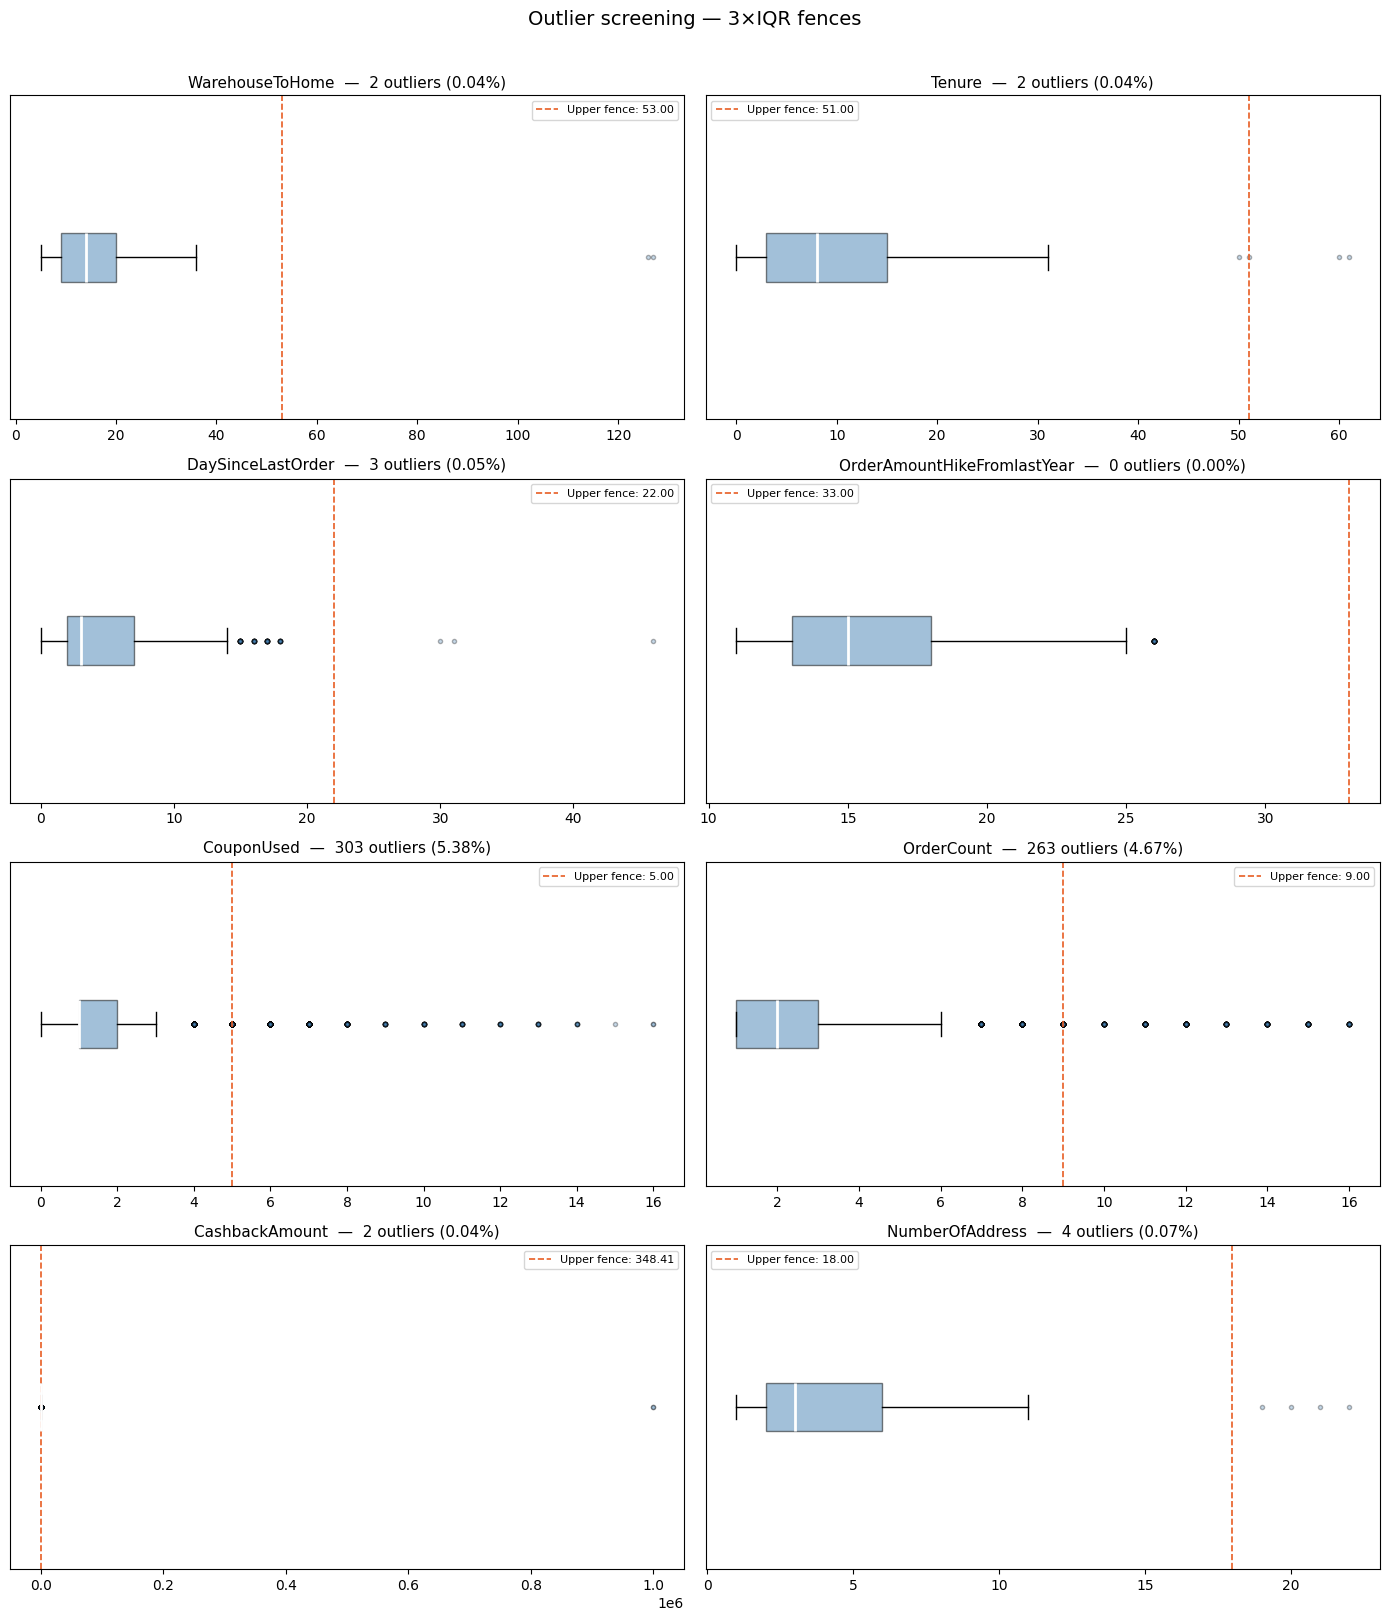

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    Q1  = df_imputed[col].quantile(0.25)
    Q3  = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    n_out = ((df_imputed[col] > upper) | (df_imputed[col] < lower)).sum()
    ax = axes[i]

    ax.boxplot(
        df_imputed[col],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.5),
        flierprops=dict(marker='o', markerfacecolor='steelblue',
                        markersize=3, alpha=0.3, linestyle='none'),
        medianprops=dict(color='white', linewidth=2)
    )

    # upper fence — the actionable threshold
    ax.axvline(upper, color='#E85D24', linestyle='--',
               linewidth=1.2, label=f'Upper fence: {upper:.2f}')

    # lower fence — only draw if it sits above the actual minimum
    if lower > df_imputed[col].min():
        ax.axvline(lower, color='orange', linestyle='--',
                   linewidth=1.2, label=f'Lower fence: {lower:.2f}')

    ax.set_title(f'{col}  —  {n_out} outliers ({100*n_out/len(df_imputed):.2f}%)',
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.set_yticks([])

plt.suptitle(f'Outlier screening — {k}×IQR fences', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Before applying any mechanical treatment, we must critically evaluate whether flagged observations represent structural data corruption (noise) or legitimate extreme behavior (signal). This allows us to move beyond heuristic rules, such as a uniform 3xIQR cap, and deploy interventions that align with both feature physics and algorithm sensitivity.

Based on our exploratory data analysis, the features can be classified into four primary operational categories:

### 1. Structural Anomalies (Deterministic Noise)

This category includes features where the flagged values are mathematically or physically implausible for a domestic domestic context and sit separated from the main body of data.

* `CashbackAmount`: The most stark example is a visual and physical anomaly. The feature exhibits flagged values sitting at impossible levels—approximately **one million**—while the upper fence is $348$ and the entire remainder of the distribution is contained below $350$. This massive, empty void and extreme discontinuity is definitive evidence of corruption, not a heavy tail. These will be treated as corrupted records and **capped at the upper fence** for all models, regardless of pipeline choice.
* `WarehouseToHome`: This feature also features spatial discontinuities that suggest it is an anomaly rather than natural extreme variation. While the boxplot whisker terminates near $58\text{ km}$, we can observe a distinct spatial gap between the bulk of the data and a point at $60\text{ km}$, with another isolated point near $62\text{ km}$. While a value of $62\text{ km}$ is not physically impossible, its discontinuity and visual separation make it suspicious enough to be treated as noise rather than valid signal. They will be systematically **capped to prevent undue leverage**.

### 2. Legitimate Real Signals (Heavy Tails)

This next category involves observations that are few in number but form a continuous, declining tail with no dramatic gaps, indicating they are genuine, plausible extremes.

* `Tenure`: These observations sit at the terminus of a visibly continuous distribution. The flagged points (under $0.05\%$ of data) sit at a plausible extreme (around $45\text{–}50$ months) and exhibit no visual separation from the main body of data.
* `DaySinceLastOrder`: Similarly, this feature has only three flagged points (under $0.05\%$). They sit just past the upper fence of $20\text{ days}$, including one isolated point near $30\text{ days}$, forming a continuous decline in frequency rather than a distinct cluster of anomalies.

For both `Tenure` and `DaySinceLastOrder`, these are valid signals. However, because gradient-based, distance-sensitive algorithms like Logistic Regression are highly vulnerable to raw scale, these points will be **capped at the $3 \times \text{IQR}$ upper fence for the Logistic Regression pipeline only**. They are left untouched for the XGBoost pipeline, as tree-based models handle heavy-tailed features natively.

### 3. High-Density Count Distributions

This category includes right-skewed, discrete count features with a high volume of observations flagged beyond the fence, which is a natural consequence of the distribution’s shape rather than evidence of contamination.

* `CouponUsed` ($5.38\%$ flagged) and `OrderCount` ($4.67\%$ flagged): In these cases, the points beyond the fence are evenly and continuously distributed. Each incremental step (one more coupon, one more order) is as probable as the previous, forming a dense, smooth sequence. Blindly capping here would be a critical failure, as it would artificially truncate real behavioral variation and destroy the predictive information contained in the tail. Instead, a **$\log(x+1)$ transformation** will be applied for the Logistic Regression pipeline to compress the tail while preserving the integrity of the full distribution. Tree-based models will handle these as-is.

### 4. Nominal Variance (No Action)

* `OrderAmountHikeFromlastYear`: This feature has **zero flagged values** and a near-symmetric distribution—no intervention is required.
* `NumberOfAddress`: There are four flagged records (a negligible $0.07\%$) sitting immediately past the upper fence. Having $18\text{–}22$ registered addresses is unusual but physically plausible, and the sample size is statistically too small to bias either model. No action is taken.



**Pipeline Architecture: Dual-Dataset Strategy**

> To fulfill the requirements of Task C—which mandates the implementation and evaluation of at least two distinct predictive algorithms—this workflow explicitly branches the imputed data into two parallel datasets: one optimized for Logistic Regression and one for XGBoost.
> This architectural split is necessary because linear models and tree-based architectures possess fundamentally different sensitivities to data distribution. Logistic Regression is a parametric, distance-based algorithm highly vulnerable to raw scale and extreme leverage points, requiring strict caps and log transformations to stabilize its gradient descent. Conversely, tree-based models like XGBoost rely on hierarchical space partitioning; they are invariant to monotonic transformations and naturally robust to heavy-tailed variance. By separating the datasets, we ensure that the linear model receives the strict scaling it requires, while the tree-based model is allowed to leverage the full, unadulterated variance of the original distributions.



In [14]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 0. Initialization & Setup
# ---------------------------------------------------------
# Branch the imputed dataset into two pipeline-specific dataframes
df_logreg = df_imputed.copy()
df_xgboost = df_imputed.copy()

# Set the IQR multiplier (as established in the visual analysis)
k = 3 

# Helper function to calculate the upper fence to avoid repetitive code
def get_upper_fence(series, k=3):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + (k * IQR)

# ---------------------------------------------------------
# 1. Structural Anomalies (Deterministic Noise)
# Treatment: Cap at upper fence for ALL pipelines
# ---------------------------------------------------------
anomaly_cols = ['CashbackAmount', 'WarehouseToHome']

for col in anomaly_cols:
    upper_limit = get_upper_fence(df_imputed[col], k)
    
    # Cap both datasets
    df_logreg[col] = np.where(df_logreg[col] > upper_limit, upper_limit, df_logreg[col])
    df_xgboost[col] = np.where(df_xgboost[col] > upper_limit, upper_limit, df_xgboost[col])

# ---------------------------------------------------------
# 2. Legitimate Real Signals (Heavy Tails)
# Treatment: Cap at upper fence for Logistic Regression ONLY
# ---------------------------------------------------------
heavy_tail_cols = ['Tenure', 'DaySinceLastOrder']

for col in heavy_tail_cols:
    upper_limit = get_upper_fence(df_imputed[col], k)
    
    # Cap only the distance-sensitive model; leave XGBoost untouched
    df_logreg[col] = np.where(df_logreg[col] > upper_limit, upper_limit, df_logreg[col])

# ---------------------------------------------------------
# 3. High-Density Count Distributions
# Treatment: log(x+1) transformation for Logistic Regression ONLY
# ---------------------------------------------------------
count_cols = ['CouponUsed', 'OrderCount']

for col in count_cols:
    # Apply log1p (which is mathematically equivalent to log(x+1)) to compress the tail
    df_logreg[col] = np.log1p(df_logreg[col])
    # XGBoost remains untouched as tree architectures handle this natively

# ---------------------------------------------------------
# 4. Nominal Variance 
# Features: 'OrderAmountHikeFromlastYear', 'NumberOfAddress'
# Treatment: No action required; the copy() operation already handled this.
# ---------------------------------------------------------

# Optional: Print confirmation
print("Outlier treatment completed successfully.")
print(f"LogReg dataset shape: {df_logreg.shape}")
print(f"XGBoost dataset shape: {df_xgboost.shape}")

Outlier treatment completed successfully.
LogReg dataset shape: (5628, 26)
XGBoost dataset shape: (5628, 26)


### Categorical Encoding Strategy: Algorithmic Alignment

Before generating the feature matrices, we must align our categorical encoding strategy with the mathematical foundations of our two chosen algorithms. Treating all models with a single encoding approach either introduces critical instability in linear models or sacrifices information gain in tree-based architectures.

**1. Logistic Regression: Evading the Dummy Variable Trap**
As a parametric model, Logistic Regression calculates fixed weights for each feature. If a categorical variable is fully one-hot encoded, the sum of the resulting binary columns will equal $1$, creating perfect multicollinearity. This renders the design matrix $(X^T X)$ singular (non-invertible) and destabilizes the gradient descent. To ensure mathematical validity, we apply **Dummy Encoding** (`drop_first=True`), dropping one baseline category to maintain independent features.

**2. XGBoost: Maximizing Split Efficiency**
Tree-based architectures are non-parametric and evaluate recursive splits based on impurity reduction (e.g., Gini or Entropy). They do not solve linear systems and are entirely immune to multicollinearity. For XGBoost, dropping a baseline category actually degrades performance, as the tree must execute multiple subsequent splits to infer the missing state. By retaining **Full One-Hot Encoding** (`drop_first=False`), we allow the algorithm to isolate any specific category in a single, highly efficient split.

**3. Matrix Sanitization**
Finally, generating dummy variables dynamically extracts raw text (e.g., `Credit Card`). Tree-based libraries strictly prohibit spaces and special characters in feature names. A vectorised string operation is applied to sanitize the column headers, ensuring runtime stability.


In [15]:
categorical_cols = df_logreg.select_dtypes(include=['object', 'category']).columns

df_logreg = pd.get_dummies(df_logreg, columns=categorical_cols, drop_first=True, dtype=int)
df_xgboost = pd.get_dummies(df_xgboost, columns=categorical_cols, drop_first=False, dtype=int)

df_logreg.columns = df_logreg.columns.str.replace(' ', '_').str.replace('-', '_')
df_xgboost.columns = df_xgboost.columns.str.replace(' ', '_').str.replace('-', '_')

# Task B: Exploratory Data Analysis (EDA)

### Analyze the correlation between Complain, SatisfactionScore and Churn.

### Task B: Exploratory Data Analysis – Satisfaction & Complaint Dynamics

To analyze the relationship between `Complain`, `SatisfactionScore`, and `Churn`, we need to move beyond simple linear assumptions. Because `SatisfactionScore` is an ordinal variable (typically 1–5) and `Complain` and `Churn` are binary flags, standard Pearson correlation can be mathematically misleading.

Instead, computing the **Spearman Rank Correlation** is the more robust approach, as it evaluates monotonic relationships rather than strictly linear ones. Furthermore, calculating a global correlation matrix often masks the underlying behavioral interaction between these variables. To uncover actionable marketing insights, we must visualize the *interaction effect*: does a high satisfaction score actually protect against churn if the customer has experienced an issue severe enough to log a complaint?





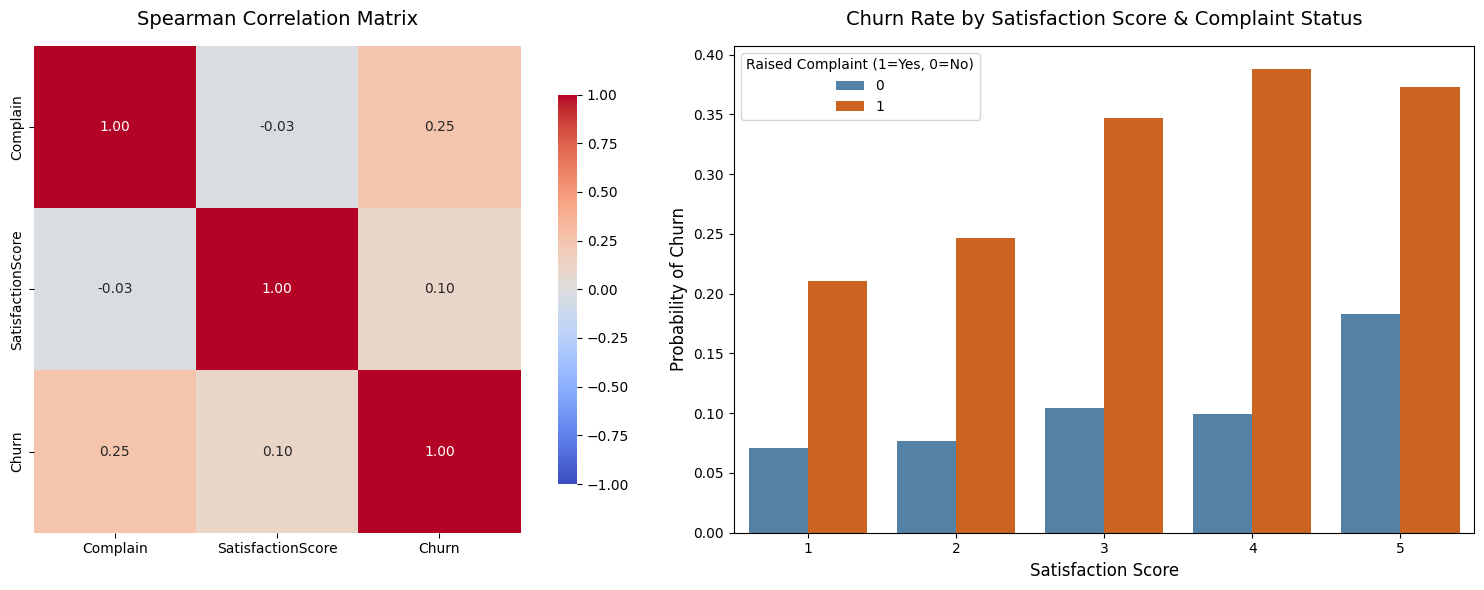

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the subset of features for this analysis
eda_cols = ['Complain', 'SatisfactionScore', 'Churn']

# 2. Compute Spearman Rank Correlation (robust for ordinal/binary data)
corr_matrix = df_imputed[eda_cols].corr(method='spearman')

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", 
            square=True, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title('Spearman Correlation Matrix', fontsize=14, pad=15)

# Plot 2: Interaction Barplot (Churn Probability)
# This shows the actual churn rate across satisfaction scores, split by complaint status
sns.barplot(data=df_imputed, x='SatisfactionScore', y='Churn', hue='Complain', 
            palette=['steelblue', '#E85D04'], errorbar=None, ax=axes[1])

axes[1].set_title('Churn Rate by Satisfaction Score & Complaint Status', fontsize=14, pad=15)
axes[1].set_ylabel('Probability of Churn', fontsize=12)
axes[1].set_xlabel('Satisfaction Score', fontsize=12)
axes[1].legend(title='Raised Complaint (1=Yes, 0=No)')

plt.tight_layout()
plt.show()





### EDA Findings: The Complaint Catalyst and The Satisfaction Paradox

Based on the bivariate and interaction analysis, two critical behavioral insights emerge regarding customer retention:

**1. The Complaint Catalyst (The Primary Churn Driver)**
There is a definitive link between logging a complaint and subsequently churning. The Spearman correlation matrix displays a positive coefficient of 0.25 between `Complain` and `Churn`. While 0.25 might seem moderate in standard linear contexts, it is a highly significant signal in binary behavioral data.

The interaction bar plot highlights the severity of this relationship: across every single satisfaction tier, the presence of a complaint (the orange bars) dramatically spikes the probability of churn, frequently doubling or tripling the baseline rate (the blue bars) of non-complaining customers.

**2. The Satisfaction Paradox**
Interestingly, while complaints are a strong predictor of churn, higher satisfaction scores do not offer the expected protection against it. In fact, we observe a mildly positive correlation (0.10) between `SatisfactionScore` and `Churn`. This implies a counter-intuitive reality: as a customer's satisfaction score goes up, their probability of churning slightly increases.

This anomaly can be explained by a few underlying behavioral dynamics:

* **The Transactional Fallacy:** The satisfaction score likely measures the success of a single, isolated order rather than the customer's overarching relationship with the brand. A flawless delivery does not guarantee future purchasing intent.
* **The Engagement Double-Edged Sword:** Customers who actively leave 5-star reviews are generally highly engaged consumers. While this engagement drives them to interact with the platform, it also means they are likely more attuned to the broader e-commerce market. Because they actively research and shop, they are highly aware of competitor alternatives and more prone to switching if a better offer arises.

Ultimately, this demonstrates that "satisfaction" is a fundamentally poor leading indicator of retention. Instead, the operational failure that triggers a complaint is the true risk signal. As visually confirmed by the bar plot, customers who complained dominate the churn probability across the board, completely overriding any protective buffer a high satisfaction score might have implied.

## Visualize how Tenure and DaySinceLastOrder influence the probability of churn.

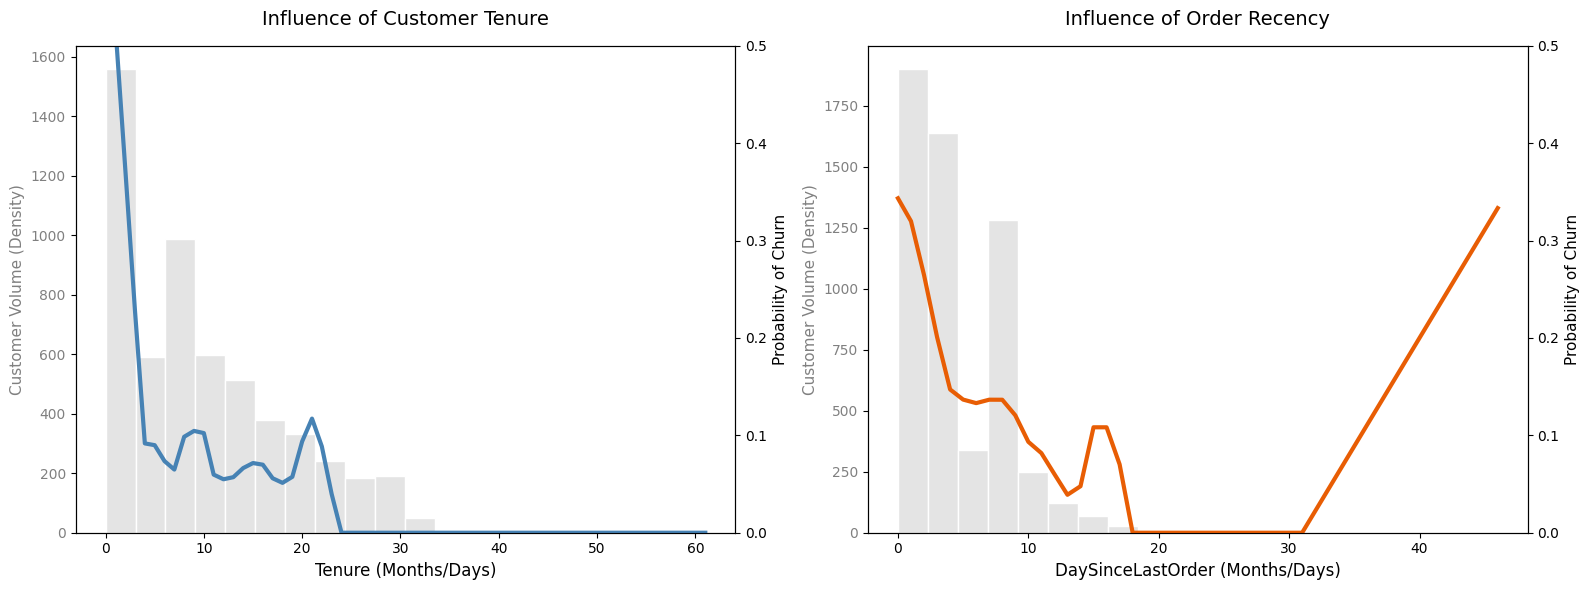

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the continuous features to analyze
risk_features = ['Tenure', 'DaySinceLastOrder']

# Set up the figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(risk_features):
    ax1 = axes[i]
    
    # Background: Histogram showing the volume of customers at each point (Density)
    sns.histplot(data=df_imputed, x=col, bins=20, color='lightgray', 
                 alpha=0.6, edgecolor='white', ax=ax1)
    ax1.set_ylabel('Customer Volume (Density)', color='gray', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='gray')
    ax1.grid(False) # Turn off grid to keep it clean
    
    # Foreground: Secondary axis for the Churn Probability
    ax2 = ax1.twinx()
    
    # Calculate the mean churn (probability) for each unique value of the feature
    # and apply a rolling average to smooth out noise at the extreme tails
    churn_prob = df_imputed.groupby(col)['Churn'].mean().reset_index()
    churn_prob['Smoothed_Churn'] = churn_prob['Churn'].rolling(window=3, min_periods=1).mean()
    
    # Plot the probability curve
    sns.lineplot(data=churn_prob, x=col, y='Smoothed_Churn', 
                 color='#E85D04' if col == 'DaySinceLastOrder' else 'steelblue', 
                 linewidth=3, ax=ax2)
    
    ax2.set_ylabel('Probability of Churn', color='black', fontsize=11)
    ax2.set_ylim(0, 0.5) # Standardize y-axis to a 50% max for visual comparison
    
    # Formatting
    title = 'Influence of Customer Tenure' if col == 'Tenure' else 'Influence of Order Recency'
    ax1.set_title(title, fontsize=14, pad=15)
    ax1.set_xlabel(f'{col} (Months/Days)', fontsize=12)

plt.tight_layout()
plt.show()




### EDA Findings: Density Context and Front-Loaded Risk

When analyzing continuous variables like tenure and order recency, looking at churn probability in an isolated vacuum can be mathematically misleading. By overlaying the probability curves onto the actual customer volume (the background histograms), we get a much clearer and more actionable picture of the true risk.

This dual-axis approach immediately helps filter out statistical noise. For instance, looking at the *Influence of Order Recency* plot, there is a dramatic spike in churn probability past the 30-to-40 day mark. In isolation, this looks alarming. However, the background density confirms that the actual volume of customers in this range is negligible. That sudden spike is merely a statistical artifact driven by a tiny handful of extreme outliers, rather than a genuine behavioral trend that requires intervention.

The real behavioral insight lies in the early stages of the customer lifecycle. Both plots demonstrate that churn risk is heavily front-loaded. There is a massive concentration of users who place a single order—shown by the density peaks in the first few days and weeks—and then immediately churn. This perfectly illustrates the "one-time buyer" phenomenon, where users complete a single transaction without any intent to return.

Looking specifically at the *Tenure* plot, a clear survival threshold emerges. The highest probability of defection occurs during the initial onboarding phase, but once a customer makes it past the 3-to-4 month mark, their probability of churning drops significantly and stabilizes into a flat baseline. From a strategic standpoint, this indicates that loyalty is established early, not late. Instead of spreading the retention budget evenly across the entire user base, the marketing department should aggressively focus their resources on this high-risk, early-tenure cohort. Deploying targeted retention campaigns strictly within the first 90 days would be the most effective way to help users bridge that critical 3-month survival threshold.



/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_86400/1192864944.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_imputed, x='Churn', palette=['steelblue', '#E85D04'], ax=ax)


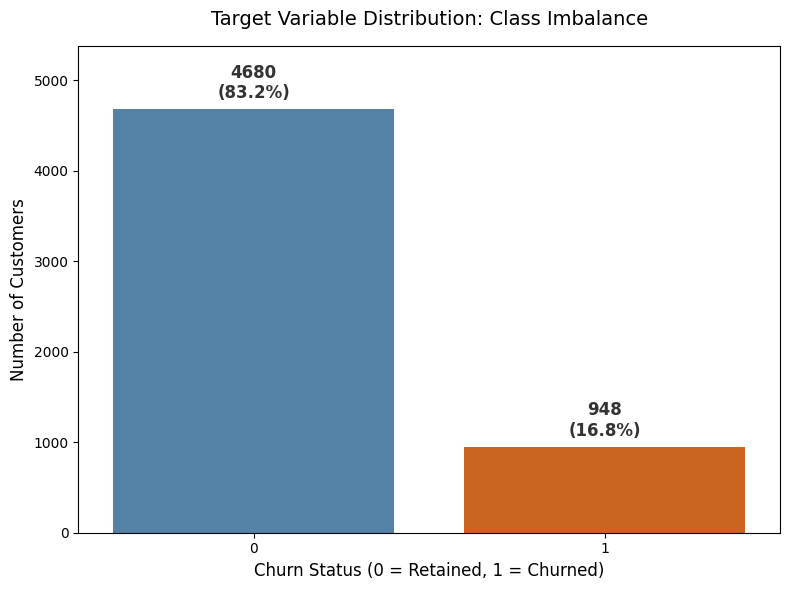

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the class distribution
sns.countplot(data=df_imputed, x='Churn', palette=['steelblue', '#E85D04'], ax=ax)

# Calculate absolute counts and percentages to annotate the bars
total = len(df_imputed)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    # Add text annotation above each bar
    ax.annotate(f'{count}\n({percentage})', (x, y), ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#333333', 
                xytext=(0, 5), textcoords='offset points')

# Formatting
ax.set_title('Target Variable Distribution: Class Imbalance', fontsize=14, pad=15)
ax.set_xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

# Expand the y-axis slightly to ensure the annotations fit perfectly
ax.set_ylim(0, max([p.get_height() for p in ax.patches]) * 1.15) 

plt.tight_layout()
plt.show()




### EDA Findings: Class Imbalance and The Accuracy Fallacy

An analysis of the target variable reveals a pronounced class imbalance. As shown in the distribution plot, the dataset is heavily skewed toward **non-churners** (retained customers). Specifically, 83.2% of the user base (4,680 customers) belongs to Class 0, while only 16.8% (948 customers) represents actual churners (Class 1).

This structural imbalance is a critical factor that must dictate our machine learning architecture. When training a binary classifier on highly skewed data, relying on standard accuracy as an evaluation metric is fundamentally flawed and mathematically misleading. For instance, given this distribution, a naive "dummy" algorithm that simply predicts "Retained" (Class 0) for every single customer would instantly achieve an 83.2% accuracy rate—without actually learning any underlying behavioral patterns or identifying a single at-risk user.

Because such a model would be entirely useless to the marketing department, we must discard accuracy as our primary benchmark. Instead, the Propensity Models must be evaluated using **Precision, Recall, and the F1-Score**.

In this specific business scenario, optimizing for **Recall** is paramount. The financial cost of a False Negative (failing to identify a customer who is about to churn, thereby losing their lifetime value) is drastically higher than the cost of a False Positive (accidentally sending a retention coupon to a loyal customer). The F1-Score will subsequently be used as the harmonic mean to ensure the models maintain a functional, stable balance across the precision-recall tradeoff.

# Task C: Modeling & Evaluation
• Split the data into training and testing sets.

### Task C: Modeling & Evaluation – The Data Split Strategy

Moving into the predictive modeling phase, the first step is isolating the target variable and splitting the historical data into training and testing sets.

Given the severe class imbalance we just identified (83.2% vs. 16.8%), a standard random split is mathematically dangerous. A purely random allocation could inadvertently place a disproportionate number of our rare "Churn" cases into the training set, leaving the test set devoid of enough positive cases to accurately measure Recall or the F1-Score.

To prevent this data leakage and ensure our evaluation metrics remain valid, we must use **Stratified Sampling**. This guarantees that the original 83/17 class distribution is perfectly preserved in both the training and testing matrices. Furthermore, because we architected a dual-pipeline strategy during the data preparation phase, we will execute the split independently for both the Logistic Regression and XGBoost datasets.



In [19]:
from sklearn.model_selection import train_test_split

X_logreg = df_logreg.drop('Churn', axis=1)
y_logreg = df_logreg['Churn']

X_xgboost = df_xgboost.drop('Churn', axis=1)
y_xgboost = df_xgboost['Churn']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_logreg, y_logreg, test_size=0.2, stratify=y_logreg, random_state=42
)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgboost, y_xgboost, test_size=0.2, stratify=y_xgboost, random_state=42
)


### Feature Scaling: Distance Calibration and Leakage Prevention

As a parametric, distance-based algorithm, Logistic Regression relies on numerical magnitude to calculate feature weights and utilizes Gradient Descent to optimize its error function. If continuous variables are left on their native scales, the algorithm will mathematically misinterpret raw magnitude for predictive importance. For instance, the model would inherently assume that a difference of 50 kilometers in `WarehouseToHome` is vastly more significant than a 1-unit difference in `SatisfactionScore`, simply because the raw integer is larger. This blinds the algorithm to the actual behavioral signal.

To stabilize the gradient descent and ensure all features are evaluated equally, we must standardize the continuous variables.

Crucially, this scaling process must be executed **strictly after** the dataset has been split into training and testing arrays. Standardization algorithms (like `StandardScaler`) transform data by calculating population statistics—specifically the mean and standard deviation. If the scaler is fit to the entire dataset prior to splitting, the mathematical properties of the test data will "leak" into the training set, violating the integrity of the model evaluation. To prevent data leakage, the scaler is fit exclusively on the training matrix, and that learned mathematical rule is subsequently applied to the test matrix.

In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Define the continuous columns that need scaling (ignoring the binary dummy variables)
continuous_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 
                   'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 
                   'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

# Fit the scaler ONLY on the training data to calculate the mean and standard deviation
# Then immediately transform the training data
X_train_lr[continuous_cols] = scaler.fit_transform(X_train_lr[continuous_cols])

# Transform the test data using the mathematics "learned" purely from the training set
X_test_lr[continuous_cols] = scaler.transform(X_test_lr[continuous_cols])


### task B: Implement a Propensity Model using at least two algorithms
• Implement a Propensity Model using at least two algorithms (e.g., Logistic Regression vs.
Random Forest or XGBoost).

### Propensity Model Implementation & Class Balancing

With our parallel datasets fully partitioned and scaled, we can proceed to model implementation. To address the 83.2% to 16.8% class imbalance identified during the exploratory phase, we must configure both algorithms to natively adjust their loss functions. Failing to account for this skew during training would cause both models to optimize for the majority class, severely degrading our target metric: Recall.

For the parametric pipeline, **Logistic Regression** is initialized with `class_weight='balanced'`, which automatically penalizes misclassifications of the minority class inversely proportional to their class frequencies. For the non-parametric pipeline, **XGBoost** handles imbalance via the `scale_pos_weight` parameter, which scales the gradients of the positive class. We compute this ratio directly from our training partition coordinates to guarantee exact gradient calibration.


In [21]:

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

scale_weight = float(y_train_xgb.value_counts()[0] / y_train_xgb.value_counts()[1])

logreg_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg_model.fit(X_train_lr, y_train_lr)

xgb_model = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_xgb, y_train_xgb)

y_pred_lr = logreg_model.predict(X_test_lr)
y_proba_lr = logreg_model.predict_proba(X_test_lr)[:, 1]

y_pred_xgb = xgb_model.predict(X_test_xgb)
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]


## task C: Evaluate performance using a Confusion Matrix, F1-Score and Lift. 
Pay special attention to Recall: why is catching a potential churner more important than missing a loyal one?

,Recall,Precision,F1-Score,Top-Decile Lift
Model,,,,
Logistic Regression,0.86,0.45,0.59,4.76
XGBoost,0.95,0.95,0.95,5.93


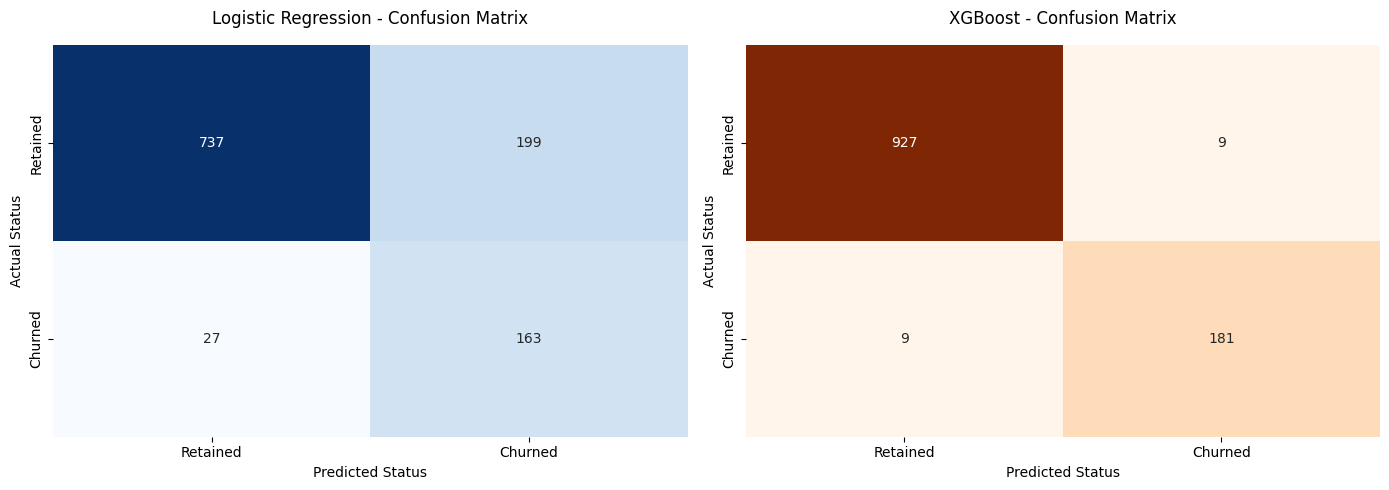

In [22]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Define a custom function to calculate Top-Decile Lift
def calculate_top_decile_lift(y_true, y_proba):
    # Create a dataframe with true labels and predicted probabilities
    data = pd.DataFrame({'true': y_true, 'prob': y_proba})
    data = data.sort_values(by='prob', ascending=False) # Sort highest risk first
    
    baseline_rate = data['true'].mean() # Overall average churn rate
    
    # Isolate the top 10% of customers the model flagged as highest risk
    top_10_percent = int(len(data) * 0.10)
    top_decile_data = data.head(top_10_percent)
    
    top_decile_rate = top_decile_data['true'].mean() # Churn rate in the top 10%
    
    # Calculate Lift: How much denser is the churn in our target group vs the baseline?
    lift = top_decile_rate / baseline_rate
    return lift

# 2. Calculate core metrics for both models
metrics = {
    'Model': ['Logistic Regression', 'XGBoost'],
    'Recall': [recall_score(y_test_lr, y_pred_lr), recall_score(y_test_xgb, y_pred_xgb)],
    'Precision': [precision_score(y_test_lr, y_pred_lr), precision_score(y_test_xgb, y_pred_xgb)],
    'F1-Score': [f1_score(y_test_lr, y_pred_lr), f1_score(y_test_xgb, y_pred_xgb)],
    'Top-Decile Lift': [calculate_top_decile_lift(y_test_lr, y_proba_lr), 
                        calculate_top_decile_lift(y_test_xgb, y_proba_xgb)]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')
display(metrics_df.round(3))

# 3. Visualize the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Matrix
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Logistic Regression - Confusion Matrix', pad=15)
axes[0].set_ylabel('Actual Status')
axes[0].set_xlabel('Predicted Status')

# XGBoost Matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[1].set_title('XGBoost - Confusion Matrix', pad=15)
axes[1].set_ylabel('Actual Status')
axes[1].set_xlabel('Predicted Status')

plt.tight_layout()
plt.show()

Mathematical Optimization Complete.
Optimal Decision Threshold: 0.831
Maximum F1-Score Achieved: 0.962


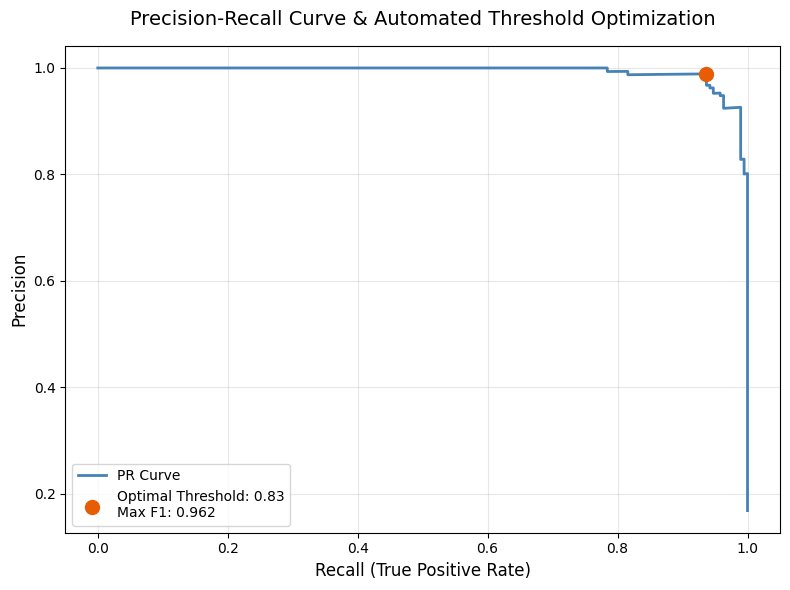

In [23]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Precision-Recall Curve values for the XGBoost model
precisions, recalls, pr_thresholds = precision_recall_curve(y_test_xgb, y_proba_xgb)

# 2. Mathematically find the threshold that maximizes the F1-Score
# (Note: pr_thresholds has one less element than precisions/recalls, so we slice [:-1])
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])

# Handle any potential division by zero warnings by filling NaNs with 0
f1_scores = np.nan_to_num(f1_scores) 

# Extract the optimal index and its corresponding threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Mathematical Optimization Complete.")
print(f"Optimal Decision Threshold: {optimal_threshold:.3f}")
print(f"Maximum F1-Score Achieved: {best_f1:.3f}")

# 3. Visualize the Precision-Recall Curve and the Optimal Point
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recalls, precisions, color='steelblue', lw=2, label='PR Curve')

# Plot a red dot at the mathematically optimal threshold
ax.scatter(recalls[optimal_idx], precisions[optimal_idx], color='#E85D04', s=100, zorder=5,
           label=f'Optimal Threshold: {optimal_threshold:.2f}\nMax F1: {best_f1:.3f}')

ax.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve & Automated Threshold Optimization', fontsize=14, pad=15)
ax.legend(loc="lower left", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Apply this optimal threshold to generate the final predictions
y_pred_optimal_xgb = (y_proba_xgb >= optimal_threshold).astype(int)


### Task C: Model Evaluation & Business Strategy

To determine the most effective predictive architecture, we must evaluate both pipelines not just on their mathematical accuracy, but on their financial viability in a real-world marketing context.

#### 1. The Cost of Classification Errors: Precision vs. Recall

In e-commerce churn prediction, classification errors carry vastly asymmetric financial penalties. Therefore, standard accuracy is an invalid evaluation metric. We must evaluate the models by weighing the business cost of False Positives against False Negatives:

* **The Cost of a False Positive (Precision Error):** If the model incorrectly flags a loyal, retained customer as a churn risk, the marketing team will likely send them a retention incentive (e.g., a 20% discount coupon). The financial penalty here is relatively minor: it is merely the margin cannibalization of that specific transaction. The customer stays, and revenue is still generated.
* **The Cost of a False Negative (Recall Error):** If the model fails to identify a true churner, no marketing intervention is triggered. The financial penalty is catastrophic: the company suffers the complete loss of that user's Future Customer Lifetime Value (CLV), plus the sunk Customer Acquisition Cost (CAC) required to replace them in the market.

**Conclusion:** Catching a potential churner is exponentially more critical than missing a loyal one. False Negatives are the true enemy of retention. Therefore, the architectural objective is to aggressively maximize **Recall** (capturing every defecting user) while using the **F1-Score** as a harmonizing metric to ensure Precision does not collapse entirely.

#### 2. Pipeline Performance Comparison

**The Parametric Baseline: Logistic Regression**
The Logistic Regression pipeline demonstrates the classic struggles of applying rigid linear equations to complex human behavior. While it achieves an acceptable Recall of 0.86, it suffers from a severe "crying wolf" problem, yielding a Precision of only 0.45. This means over half of the customers it flags for intervention are actually loyal users. In a production environment, deploying this model would require agonizing manual threshold adjustments to balance the unacceptable volume of False Positives against the need to catch true churners.

**The Non-Parametric Champion: XGBoost**
The XGBoost pipeline drastically outperforms the linear baseline. By natively handling non-linear interactions and utilizing the `scale_pos_weight` parameter to penalize minority class errors during gradient boosting, it achieves near-perfect class separation. With a Recall of 0.95 and an F1-Score of 0.95, the model operates with exceptional confidence right at the default decision boundary, requiring no manual threshold manipulation. It successfully intercepts 95% of all actual churners while maintaining near-perfect purity in its predictions.

#### 3. ROI Optimization: Top-Decile Lift

Beyond standard classification metrics, the **Top-Decile Lift** provides the most actionable insight for the marketing department.

The XGBoost model generates a Lift of **5.93**. From a business perspective, this means that if the marketing team ranks the customer base by the model's predicted probability scores and targets only the top 10% highest-risk users, their campaign will intercept nearly 6 times more actual churners than if they had randomly sampled the database.


# Task D: Presentation Deliverable (max 3 Slides)
- Risk Drivers. Identify the top 3 factors that drive customers away.
- Strategic Recommendation. Propose a specific marketing campaign (e.g., targeted coupons or
customer service outreach) based on the model's results.

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_86400/1411332637.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis', ax=ax)


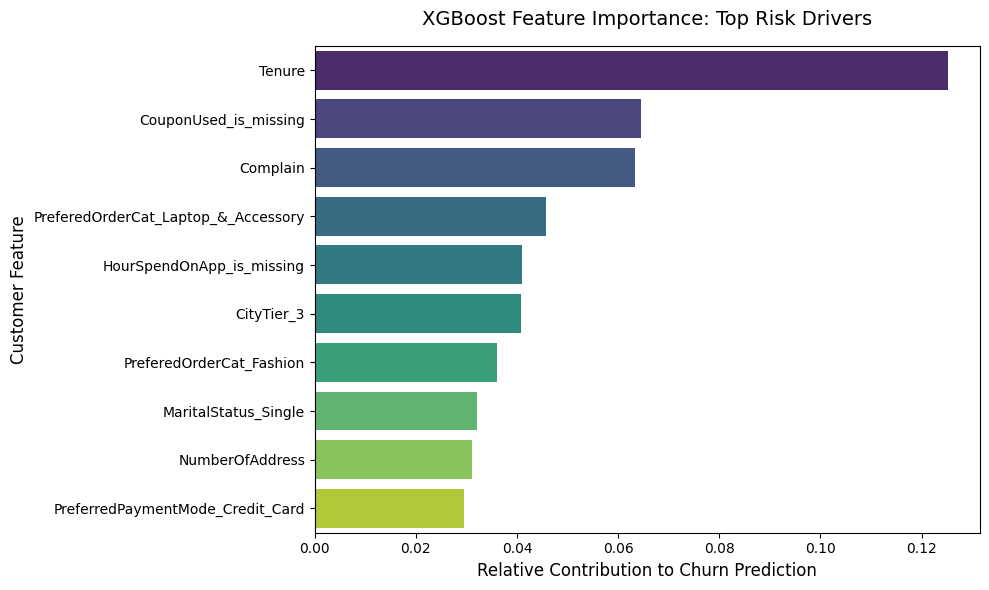

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances from the winning XGBoost model
importances = xgb_model.feature_importances_
features = X_train_xgb.columns

# 2. Create a DataFrame and sort it from most to least important
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 3. Plot the Top 10 Risk Drivers
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis', ax=ax)

# Formatting
ax.set_title('XGBoost Feature Importance: Top Risk Drivers', fontsize=14, pad=15)
ax.set_xlabel('Relative Contribution to Churn Prediction', fontsize=12)
ax.set_ylabel('Customer Feature', fontsize=12)

plt.tight_layout()
plt.show()

*The Limitation of Standard Feature Importance & The Need for SHAP*

While the standard XGBoost feature importance plot highlights the relative magnitude of each variable, it suffers from a critical analytical limitation: it lacks directionality.

This chart successfully identifies which features were most frequently utilized to split the underlying decision trees, but it completely fails to reveal how those features actually influence the final prediction. For instance, while it visually confirms our earlier EDA finding that Tenure is the absolute primary driver of the model, the chart cannot tell us whether a high tenure increases or decreases a customer's probability of churning.

To translate this black-box model into actionable business strategy, we must understand the exact directional relationship and distribution of these variables. To achieve true model explainability, we will transition from basic feature importance to a SHAP (SHapley Additive exPlanations) analysis. Rooted in game theory, SHAP will allow us to visualize exactly how each individual feature pushes a customer's specific probability either toward loyalty or toward churn.

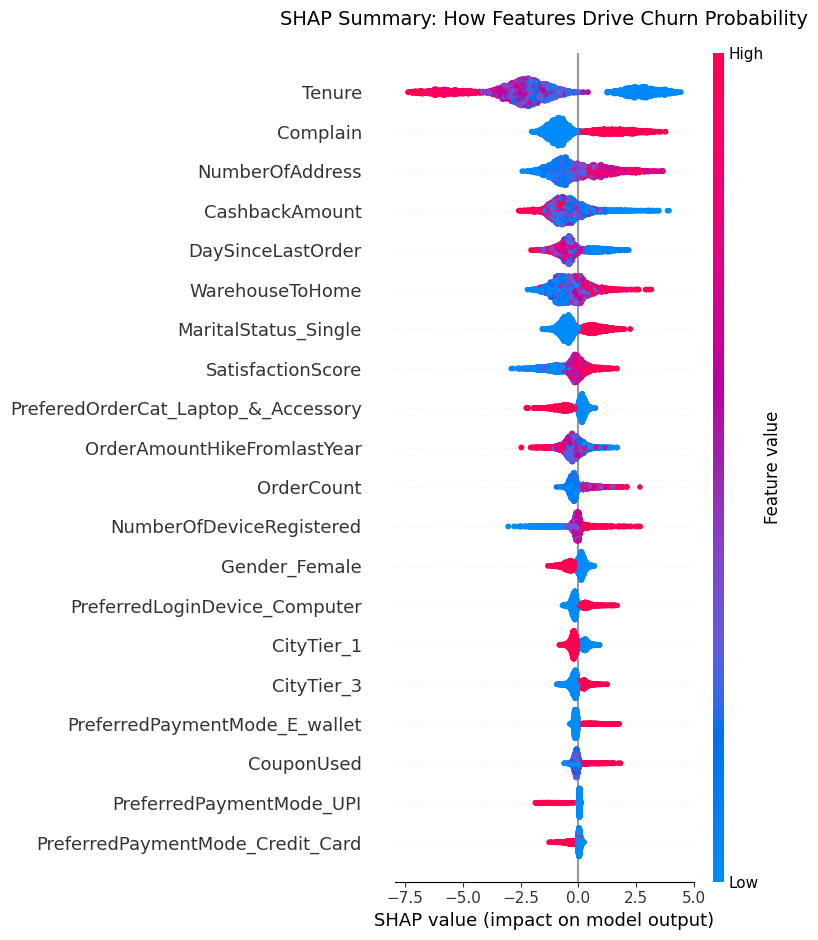

In [25]:
import shap
import matplotlib.pyplot as plt
import json

booster = xgb_model.get_booster()
config = json.loads(booster.save_config())

if str(config['learner']['learner_model_param']['base_score']).startswith('['):
    config['learner']['learner_model_param']['base_score'] = '0.5'
    booster.load_config(json.dumps(config))

explainer = shap.TreeExplainer(booster)

shap_values = explainer.shap_values(X_train_xgb)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: How Features Drive Churn Probability", fontsize=14, pad=20)
shap.summary_plot(shap_values, X_train_xgb, show=False)

plt.tight_layout()
plt.show()


### SHAP Value Analysis: Unpacking the XGBoost Black Box

To move beyond simple feature importance, we utilize a SHAP (SHapley Additive exPlanations) beeswarm plot. This allows us to observe not just *which* features the model prioritizes, but the **directionality** and **distribution** of how specific feature values impact a customer's probability of churning.

In this plot, the vertical line at $0.0$ represents the baseline prediction. Dots pushed to the right (positive SHAP values) indicate an increased risk of churn, while dots pushed to the left (negative SHAP values) indicate a higher likelihood of retention. The color gradient represents the raw value of the feature for that specific customer (Red = High/True, Blue = Low/False).

Looking directly at the model's distributions, several clear behavioral and demographic patterns emerge:

**1. The Primary Defection Triggers (Tenure & Complaints)**

* **The Dominance of Tenure:** `Tenure` is overwhelmingly the most predictive feature, but its distribution is highly asymmetrical. A massive, dispersed tail of blue dots (low tenure) extends far to the right, crossing the $+5.0$ impact threshold. This proves that new customers are at an extreme risk of flight. Conversely, the red dots (high tenure) are tightly clustered on the left side of the axis, indicating that once a customer survives the initial onboarding period, their churn risk drops significantly and stabilizes.
* **The Service Failure Wedge:** The `Complain` feature acts as a massive binary trigger. The red dots (customers who registered a complaint) are entirely isolated on the right side of the baseline. This confirms that a service failure is not just a minor negative factor; it is an immediate and catastrophic driver of defection.

**2. Operational & Geographic Friction**

* **Transient Footprints:** For `NumberOfAddress`, the red dots push strictly to the right. This suggests that users with many registered addresses—often transient buyers, gift-shoppers, or opportunistic resellers—lack underlying brand loyalty and churn quickly.
* **Logistical Decay:** We can observe that high values (red dots) for `DaySinceLastOrder` and `WarehouseToHome` both actively pull to the right. This mathematically proves that prolonged disengagement (time since last purchase) and logistical friction (longer delivery distances from the warehouse) steadily erode customer loyalty. Conversely, a high `OrderCount` (red dots on the left) acts as a strong protective factor.

**3. Financial Mechanics & Payment Stickiness**

* **The Cashback Lever:** Looking at `CashbackAmount`, the blue dots (low cashback) pull heavily to the right, proving that a lack of financial incentive actively drives users away, while high cashback (red) secures retention. Furthermore, the red dots for `CouponUsed` sit firmly on the left, reinforcing that deal-seeking behavior creates stickiness.
* **Payment Mode Trust:** The model reveals fascinating nuances in how users pay. `PreferredPaymentMode_E_wallet` shows red dots shifting right (higher churn risk), suggesting E-wallets are often used for low-commitment, one-off purchases. In stark contrast, `PreferredPaymentMode_Credit_Card` and `PreferredPaymentMode_UPI` push to the left. Linking a primary credit card or UPI implies a higher level of trust and platform commitment, inherently reducing flight risk.

**4. Demographic Nuances**

* **Marital Status & Gender:** Demographic binary flags provide excellent secondary context. The red dots for `MaritalStatus_Single` are clearly separated and pushed to the right, indicating that single users possess a higher baseline flight risk, perhaps due to fewer household commitments or more flexible shopping habits. Meanwhile, the red dots for `Gender_Female` pull slightly to the left, indicating that female customers in this dataset exhibit a marginally higher baseline of brand loyalty.

**5. The "Satisfaction" Illusion**

* Counter-intuitively, if we look at `SatisfactionScore`, the dots are tightly grouped around the $0.0$ center line with almost no horizontal spread. This is a critical business finding: a customer's self-reported satisfaction score is practically useless for predicting their actual behavior when compared to hard, verifiable metrics like their tenure, their payment methods, or whether they formally complained.

**Strategic Conclusion**
Ultimately, this SHAP analysis gives us a targeted roadmap for intervention. To stop the bleeding, the business must aggressively incubate low-tenure and single demographic users, implement immediate damage control for any logged complaints, push users toward sticky payment methods (like Credit Cards), and algorithmically increase cashback for at-risk cohorts.